# Seaborn 03 - Relational and Regression Views (Solution)

Noi dung duoc tham khao tu Seaborn docs 0.13.x (function overview, relational, categorical, grids, objects).

**Trong tam:** scatterplot/lineplot/relplot/lmplot de tim quan he bien.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
sns.set_theme(style='ticks')
from pathlib import Path
def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'data' / 'gapminder.csv').exists():
            return p
    raise FileNotFoundError('Cannot locate data/gapminder.csv from current working directory')
root = resolve_repo_root()
df = pd.read_csv(root / 'data' / 'gapminder.csv')
d2007 = df[df['year']==2007].copy()

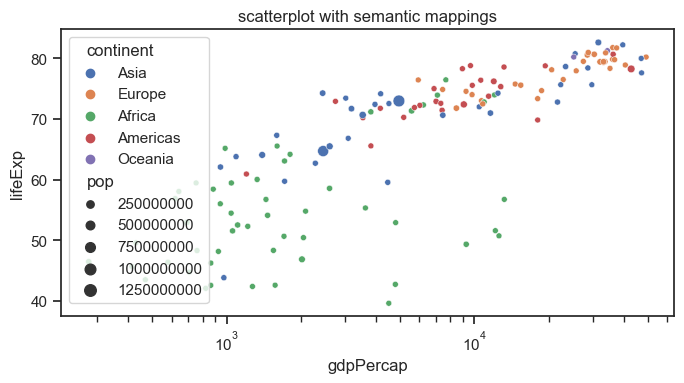

In [2]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=d2007, x='gdpPercap', y='lifeExp', hue='continent', size='pop')
plt.xscale('log')
plt.title('scatterplot with semantic mappings')
plt.tight_layout(); plt.show()

/Users/trungtv/miniforge3/envs/datalab/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/trungtv/miniforge3/envs/datalab/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


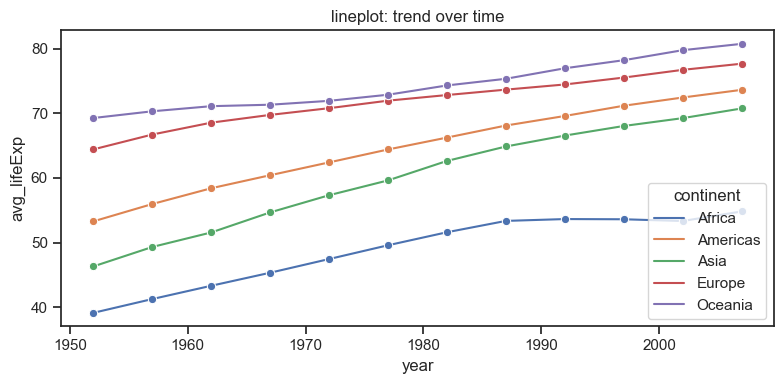

In [3]:
trend = (df.groupby(['continent','year'], as_index=False)
           .agg(avg_lifeExp=('lifeExp','mean')))
plt.figure(figsize=(8,4))
sns.lineplot(data=trend, x='year', y='avg_lifeExp', hue='continent', marker='o')
plt.title('lineplot: trend over time')
plt.tight_layout(); plt.show()

/Users/trungtv/miniforge3/envs/datalab/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


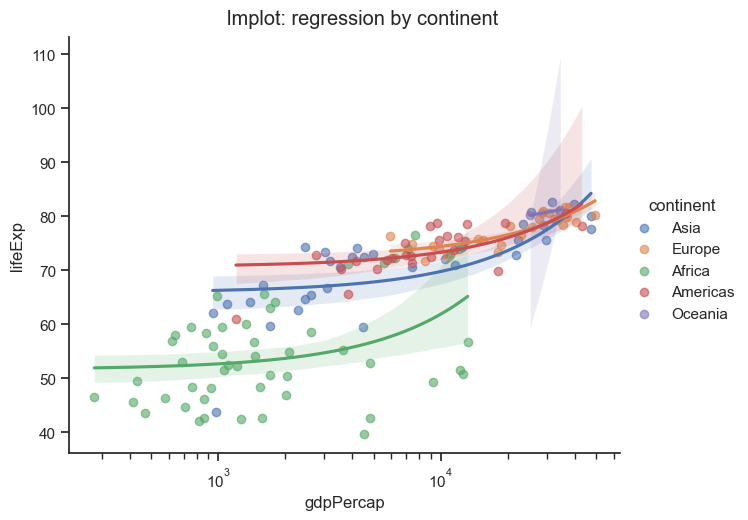

In [4]:
g = sns.lmplot(data=d2007, x='gdpPercap', y='lifeExp', hue='continent', height=5, aspect=1.3, scatter_kws={'alpha':0.6})
g.set(xscale='log')
g.fig.suptitle('lmplot: regression by continent', y=1.02)
plt.show()

## Reflection
- Chart nao phu hop nhat voi bai toan cua ban?
- Ban doi API nao de code gon hon / de maintain hon?